CandNo: 291076
Instructions for use: 
1) Have all of the files in the supplied dataset saved in the same location this notebook is saved to.
2) Run each cell sequentially.

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt


In [3]:
#Yield data preprocessing (Labels)
yield_df = pd.read_csv("Yield_and_Production_data(in).csv", encoding="ISO-8859-1")
yield_df = yield_df[yield_df['Element'] != 'Production'] # remove all rows with Production 
yield_df = yield_df.drop(columns=['Element']) # remove column for element
yield_df = yield_df.drop(columns=['Flag'])
yield_df = yield_df.drop(columns=['Domain'])
yield_df = yield_df.drop(columns=['Item Code (CPC)'])
yield_df = yield_df.rename(columns={'Value': 'Yield'})
yield_df = yield_df.copy() 
yield_df.reset_index(drop=True, inplace=True)
yield_df = yield_df[['Country','Year','Item','Yield']]
yield_df = yield_df.pivot(index=['Country', 'Year'], columns='Item', values='Yield').reset_index()
yield_df = yield_df.fillna(0)
#print(yield_df)

In [7]:
filename = "sorted_yield_data.csv"
yield_df.to_csv(filename, index=False)
print(f"Saved training data to: {filename}")

Saved training data to: sorted_yield_data.csv


In [9]:
# load features

canop_df = pd.read_csv("CanopInt_inst_data(in).csv")
esoil_df = pd.read_csv("ESoil_tavg_data(in).csv")
rain_df = pd.read_csv("Rainf_tavg_data(in).csv")
snow_df = pd.read_csv("Snowf_tavg_data(in).csv")
soil_moi_a_df = pd.read_csv("SoilMoi0_10cm_inst_data(in).csv")
soil_moi_b_df = pd.read_csv("SoilMoi10_40cm_inst_data(in).csv")
soil_moi_c_df = pd.read_csv("SoilMoi40_100cm_inst_data(in).csv")
soil_moi_d_df = pd.read_csv("SoilMoi100_200cm_inst_data(in).csv")
soil_tmp_a_df = pd.read_csv("SoilTMP0_10cm_inst_data(in).csv")
soil_tmp_b_df = pd.read_csv("SoilTMP10_40cm_inst_data(in).csv")
soil_tmp_c_df = pd.read_csv("SoilTMP40_100cm_inst_data(in).csv")
soil_tmp_d_df = pd.read_csv("SoilTMP100_200cm_inst_data(in).csv")
evap_plant_df = pd.read_csv("TVeg_tavg_data(in).csv")
water_store_df = pd.read_csv("TWS_inst_data(in).csv")
land_cover_percent_df = pd.read_csv("Land_cover_percent_data(in).csv")

centroid_df = pd.read_csv("country_latitude_longitude_area_lookup(in).csv", encoding="ISO-8859-1")

canop_df.name = "canop"
esoil_df.name = "esoil"
rain_df.name = "rain"
snow_df.name = "snow"
soil_moi_a_df.name = "soil_moi_a"
soil_moi_b_df.name = "soil_moi_b"
soil_moi_c_df.name = "soil_moi_c"
soil_moi_d_df.name = "soil_moi_d"
soil_tmp_a_df.name = "soil_tmp_a"
soil_tmp_b_df.name = "soil_tmp_b"
soil_tmp_c_df.name = "soil_tmp_c"
soil_tmp_d_df.name = "soil_tmp_d"
evap_plant_df.name = "evap_plant"
water_store_df.name = "water_store"
land_cover_percent_df.name = "land_cover"
# List of all feature csvs
all_features = [canop_df, esoil_df, rain_df, snow_df, soil_moi_a_df, soil_moi_b_df, soil_moi_c_df, soil_moi_d_df, soil_tmp_a_df, soil_tmp_b_df, soil_tmp_c_df, soil_tmp_d_df, evap_plant_df, water_store_df, land_cover_percent_df]

In [97]:
def assign_country_to_features(all_features, centroid_df, output_folder='features_with_country'):
    """
    Assigns a country to each row in multiple environmental feature DataFrames based on proximity
    to country centroids, using a KDTree for fast nearest-neighbour lookup.

    Each feature DataFrame is matched to its closest country's centroid (latitude/longitude),
    and only rows within that country's specified radius are retained. The output is saved
    as a new CSV per input feature set with an added 'country' column.

    Parameters:
        all_features (list of pd.DataFrame): List of feature DataFrames each containing 'latitude' and 'longitude' columns.
        centroid_df (pd.DataFrame): DataFrame containing 'country', 'centroid latitude', 'centroid longitude', and 'centroid radius'.
        output_folder (str): Folder where the processed CSVs will be saved.

    Returns:
        None. Saves one CSV per feature DataFrame in the specified output folder.
    """
    import pandas as pd
    import numpy as np
    from scipy.spatial import cKDTree
    import os

    # Clean centroid data by removing rows with missing or infinite coordinate/radius values
    centroid_df = centroid_df.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['centroid latitude', 'centroid longitude', 'centroid radius']
    )

    # Build a KDTree from the centroid coordinates for efficient nearest-neighbour queries
    centroid_coords = centroid_df[['centroid latitude', 'centroid longitude']].values
    centroid_tree = cKDTree(centroid_coords)

    # Create the output folder if it doesn't already exist
    os.makedirs(output_folder, exist_ok=True)

    # Iterate over each feature DataFrame in the provided list
    for df in all_features:
        try:
            # Use the DataFrame's 'name' attribute if available for naming the output file
            name = getattr(df, 'name', 'unnamed')

            # Clean feature data by removing rows with missing or infinite coordinates
            df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['latitude', 'longitude'])

            # Extract the (lat, lon) coordinates and find the nearest centroid for each row
            coords = df[['latitude', 'longitude']].values
            distances, indices = centroid_tree.query(coords, k=1)

            # Assign the nearest country name from the centroid dataframe
            df['country'] = centroid_df.iloc[indices]['country'].values

            # Mask rows where the point lies outside the centroid's defined radius
            within_radius = distances <= centroid_df.iloc[indices]['centroid radius'].values
            df.loc[~within_radius, 'country'] = np.nan

            # Drop rows with no valid country assignment
            df = df.dropna(subset=['country'])

            # Move 'country' column to the front
            cols = ['country'] + [col for col in df.columns if col != 'country']
            df = df[cols]

            # Save the cleaned and annotated DataFrame to CSV
            output_path = os.path.join(output_folder, f"{name}_with_country.csv")
            df.to_csv(output_path, index=False)
            print(f"Processed and saved: {output_path}")

        except Exception as e:
            print(f"Error processing feature DataFrame '{name}': {e}")


In [107]:
assign_country_to_features(all_features, centroid_df)

Processed and saved: features_with_country\canop_with_country.csv
Processed and saved: features_with_country\esoil_with_country.csv
Processed and saved: features_with_country\rain_with_country.csv
Processed and saved: features_with_country\snow_with_country.csv
Processed and saved: features_with_country\soil_moi_a_with_country.csv
Processed and saved: features_with_country\soil_moi_b_with_country.csv
Processed and saved: features_with_country\soil_moi_c_with_country.csv
Processed and saved: features_with_country\soil_moi_d_with_country.csv
Processed and saved: features_with_country\soil_tmp_a_with_country.csv
Processed and saved: features_with_country\soil_tmp_b_with_country.csv
Processed and saved: features_with_country\soil_tmp_c_with_country.csv
Processed and saved: features_with_country\soil_tmp_d_with_country.csv
Processed and saved: features_with_country\evap_plant_with_country.csv
Processed and saved: features_with_country\water_store_with_country.csv
Processed and saved: featur

In [11]:
feature_paths = [
    'features_with_country/canop_with_country.csv',
    'features_with_country/esoil_with_country.csv',
    'features_with_country/evap_plant_with_country.csv',
    'features_with_country/land_cover_with_country.csv',
    'features_with_country/rain_with_country.csv',
    'features_with_country/snow_with_country.csv',
    'features_with_country/soil_moi_a_with_country.csv',
    'features_with_country/soil_moi_b_with_country.csv',
    'features_with_country/soil_moi_c_with_country.csv',
    'features_with_country/soil_moi_d_with_country.csv',
    'features_with_country/soil_tmp_a_with_country.csv',
    'features_with_country/soil_tmp_b_with_country.csv',
    'features_with_country/soil_tmp_c_with_country.csv',
    'features_with_country/soil_tmp_d_with_country.csv',
    'features_with_country/water_store_with_country.csv',

]


In [13]:
# Aggregate multiple location entries for a country in a year to the mean average of those entries. 
# So each country only has one entry for each feature, for each month of each yeaar.

def aggregate_features_by_country_year(feature_paths, output_folder='aggregated_features'):
    os.makedirs(output_folder, exist_ok=True)

    for path in feature_paths:
        try:
            # Load the feature file
            df = pd.read_csv(path)

            # Ensure required columns exist
            if not all(col in df.columns for col in ['country', 'year']):
                print(f"Skipping {path} — missing 'country' or 'year' column.")
                continue

            # Drop non-numeric columns except country and year
            non_numeric = [
                col for col in df.columns
                if col not in ['country', 'year'] and not pd.api.types.is_numeric_dtype(df[col])
            ]
            df = df.drop(columns=non_numeric)

            # Group by country and year, then aggregate
            aggregated = df.groupby(['country', 'year']).mean().reset_index()

            # Save result
            filename = os.path.basename(path)
            output_path = os.path.join(output_folder, filename.replace('.csv', '_aggregated.csv'))
            aggregated.to_csv(output_path, index=False)

            print(f"Saved: {output_path}")

        except Exception as e:
            print(f"Error processing {path}: {e}")


In [15]:
# Apply aggregation to each feaure
aggregate_features_by_country_year(feature_paths)

Saved: aggregated_features\canop_with_country_aggregated.csv
Saved: aggregated_features\esoil_with_country_aggregated.csv
Saved: aggregated_features\evap_plant_with_country_aggregated.csv
Saved: aggregated_features\land_cover_with_country_aggregated.csv
Saved: aggregated_features\rain_with_country_aggregated.csv
Saved: aggregated_features\snow_with_country_aggregated.csv
Saved: aggregated_features\soil_moi_a_with_country_aggregated.csv
Saved: aggregated_features\soil_moi_b_with_country_aggregated.csv
Saved: aggregated_features\soil_moi_c_with_country_aggregated.csv
Saved: aggregated_features\soil_moi_d_with_country_aggregated.csv
Saved: aggregated_features\soil_tmp_a_with_country_aggregated.csv
Saved: aggregated_features\soil_tmp_b_with_country_aggregated.csv
Saved: aggregated_features\soil_tmp_c_with_country_aggregated.csv
Saved: aggregated_features\soil_tmp_d_with_country_aggregated.csv
Saved: aggregated_features\water_store_with_country_aggregated.csv


In [13]:
# Record the aggregated feature paths
feature_paths_aggregated = [
    'aggregated_features/canop_with_country_aggregated.csv',
    'aggregated_features/esoil_with_country_aggregated.csv',
    'aggregated_features/evap_plant_with_country_aggregated.csv',
    'aggregated_features/land_cover_with_country_aggregated.csv',
    'aggregated_features/rain_with_country_aggregated.csv',
    'aggregated_features/snow_with_country_aggregated.csv',
    'aggregated_features/soil_moi_a_with_country_aggregated.csv',
    'aggregated_features/soil_moi_b_with_country_aggregated.csv',
    'aggregated_features/soil_moi_c_with_country_aggregated.csv',
    'aggregated_features/soil_moi_d_with_country_aggregated.csv',
    'aggregated_features/soil_tmp_a_with_country_aggregated.csv',
    'aggregated_features/soil_tmp_b_with_country_aggregated.csv',
    'aggregated_features/soil_tmp_c_with_country_aggregated.csv',
    'aggregated_features/soil_tmp_d_with_country_aggregated.csv',
    'aggregated_features/water_store_with_country_aggregated.csv',
]


In [99]:
# Function to merge all separate feature tables into one

def merge_aggregated_features(feature_paths_aggregated, output_path='merged_country_year_features.csv'):
    """
    Merges multiple pre-aggregated feature CSV files (with country and year identifiers) 
    into a single DataFrame, renaming columns to avoid collisions and saving the result to disk.

    Each input file is expected to contain at least 'country' and 'year' columns. Feature 
    columns are renamed using a prefix derived from the filename to preserve origin context.

    Parameters:
        feature_paths_aggregated (list of str): List of file paths to the preprocessed feature CSVs.
        output_path (str): File path to save the merged DataFrame. Default is 'merged_country_year_features.csv'.

    Returns:
        None. Saves the merged DataFrame as a CSV file to the specified output path.
    """
    merged_df = None

    # Loop over all input feature files
    for i, path in enumerate(feature_paths_aggregated):
        try:
            df = pd.read_csv(path)

            # Ensure required keys are present
            if not all(col in df.columns for col in ['country', 'year']):
                print(f"Skipping {path} — missing 'country' or 'year'.")
                continue

            # Extract prefix for column renaming based on filename
            name = os.path.basename(path).split('_with_country')[0]

            # Select only the relevant columns (drop lat/lon for features)
            keep_cols = ['country', 'year'] + [
                col for col in df.columns if col not in ['country', 'year', 'latitude', 'longitude']
            ]
            df = df[keep_cols]

            # Rename feature columns to include source prefix (avoids name collision)
            df = df.rename(columns={col: f"{name}_{col}" for col in df.columns if col not in ['country', 'year']})

            if merged_df is None:
                # On the first file, retain lat/lon for alignment
                lat_lon = pd.read_csv(path)[['country', 'year', 'latitude', 'longitude']]
                merged_df = pd.merge(lat_lon, df, on=['country', 'year'], how='inner')
            else:
                # Merge subsequent features by country and year
                merged_df = pd.merge(merged_df, df, on=['country', 'year'], how='inner')

            print(f"Merged: {path}")

        except Exception as e:
            print(f"Error processing {path}: {e}")

    # Final save if data was successfully merged
    if merged_df is not None:
        merged_df.to_csv(output_path, index=False)
        print(f"\nFinal merged file saved to: {output_path}")
    else:
        print("No data merged — check your input files.")


In [19]:
# Apply the merge function

merge_aggregated_features(feature_paths_aggregated)

Merged: aggregated_features/canop_with_country_aggregated.csv
Merged: aggregated_features/esoil_with_country_aggregated.csv
Merged: aggregated_features/evap_plant_with_country_aggregated.csv
Merged: aggregated_features/land_cover_with_country_aggregated.csv
Merged: aggregated_features/rain_with_country_aggregated.csv
Merged: aggregated_features/snow_with_country_aggregated.csv
Merged: aggregated_features/soil_moi_a_with_country_aggregated.csv
Merged: aggregated_features/soil_moi_b_with_country_aggregated.csv
Merged: aggregated_features/soil_moi_c_with_country_aggregated.csv
Merged: aggregated_features/soil_moi_d_with_country_aggregated.csv
Merged: aggregated_features/soil_tmp_a_with_country_aggregated.csv
Merged: aggregated_features/soil_tmp_b_with_country_aggregated.csv
Merged: aggregated_features/soil_tmp_c_with_country_aggregated.csv
Merged: aggregated_features/soil_tmp_d_with_country_aggregated.csv
Merged: aggregated_features/water_store_with_country_aggregated.csv

✅ Final merged 

In [15]:
# Save merged dataframe 

merged_df = pd.read_csv("merged_country_year_features.csv")

In [23]:
def find_shape(df):
    rows, columns = df.shape
    return print(rows, columns)

In [27]:
print(merged_df.isna().sum().sum())
find_shape(merged_df)

483
2093 189


I have 483 random missung values out of ~400,000, or 0.12%. Due to this relatively small proportion of missing values I believe KNN is my most optimal stratagy for imputation.

In [17]:
# Select only numeric columns
numeric_df = merged_df.select_dtypes(include=[np.number])

# Define and apply the scaler
scaler = StandardScaler()
scaled = scaler.fit_transform(numeric_df)


In [27]:
# Define function to test imputation parameters

def evaluate_knn_k(df, k_values=[1, 3, 5, 7, 10], mask_fraction=0.05, random_state=42):
    """
    Evaluates the impact of different K values on KNN imputation accuracy.

    This function simulates missing data by randomly masking a fraction of known values,
    then imputes them using KNN with various values of K, and compares the imputed results
    against the original values using RMSE.

    Parameters:
        df (pd.DataFrame): DataFrame with numeric values to test imputation on. Should have no real missing values.
        k_values (list of int): List of K values (number of neighbours) to evaluate.
        mask_fraction (float): Fraction of the data to randomly mask for evaluation (default 0.05).
        random_state (int): Random seed for reproducibility.

    Returns:
        dict: A dictionary mapping each K to its corresponding RMSE value.
    """
    np.random.seed(random_state)

    # Preserve index and column labels for optional future use
    original_index = df.index
    original_columns = df.columns

    # Remove rows that contain real missing values to avoid interference with masking
    df_clean = df.dropna().copy()

    # Standardise the dataset before masking/imputation
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df_clean)

    # Create a random boolean mask to simulate missing values
    mask = np.random.rand(*scaled.shape) < mask_fraction
    scaled_masked = scaled.copy()
    scaled_masked[mask] = np.nan  # Apply the mask

    # Store results: K → RMSE
    results = {}
    true_vals = scaled[mask]  # Save original unmasked values for evaluation

    # Evaluate imputation performance for each K
    for k in k_values:
        imputer = KNNImputer(n_neighbors=k)
        imputed_scaled = imputer.fit_transform(scaled_masked)
        imputed_vals = imputed_scaled[mask]  # Extract imputed values at masked positions

        # Compute RMSE between true and imputed values
        rmse = np.sqrt(mean_squared_error(true_vals, imputed_vals))
        results[k] = rmse
        print(f"K = {k} → RMSE = {rmse:.4f}")

    return results



In [59]:
# Initial test for imputation params

knn_results = evaluate_knn_k(numeric_df, k_values=[5,6,7,8]) # k = 6 appears optimal

K = 5 → RMSE = 0.2486
K = 6 → RMSE = 0.2440
K = 7 → RMSE = 0.2445
K = 8 → RMSE = 0.2462


In [68]:
# Testing various seeds to discern if 6 is really optimal
# lowered masked fraction to closer resemble the future impute
def count_best_k(numeric_df, k_values=[3, 4, 5, 6], mask_fraction=0.0012, seeds=range(50)):
    """
    Runs multiple KNN-imputation evaluations across random seeds to determine which K value
    most frequently yields the lowest RMSE when imputing masked values.

    This function is useful for empirically selecting the optimal number of neighbours for 
    KNN imputation on a given dataset.

    Parameters:
        numeric_df (pd.DataFrame): A fully numeric DataFrame with no categorical data.
        k_values (list of int): List of K values to evaluate for KNN imputation.
        mask_fraction (float): Fraction of the dataset to randomly mask for evaluation (default is 0.12%).
        seeds (iterable of int): Random seeds to use for repeated experiments.

    Returns:
        dict: A dictionary mapping each K to the number of times it achieved the lowest RMSE.
    """
    from sklearn.impute import KNNImputer
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import mean_squared_error
    import numpy as np

    # Initialise counter for best-performing K across all runs
    best_k_counts = {k: 0 for k in k_values}

    # Run evaluation across different random seeds
    for seed in seeds:
        np.random.seed(seed)

        # Drop rows with real missing values
        df_clean = numeric_df.dropna().copy()

        # Standardise features
        scaler = StandardScaler()
        scaled = scaler.fit_transform(df_clean)

        # Randomly mask a small fraction of values for testing imputation
        mask = np.random.rand(*scaled.shape) < mask_fraction
        scaled_masked = scaled.copy()
        scaled_masked[mask] = np.nan

        # Store true values at masked positions for later comparison
        true_vals = scaled[mask]
        rmse_by_k = {}

        # Evaluate each K in the list
        for k in k_values:
            imputer = KNNImputer(n_neighbors=k)
            imputed_scaled = imputer.fit_transform(scaled_masked)
            imputed_vals = imputed_scaled[mask]

            rmse = np.sqrt(mean_squared_error(true_vals, imputed_vals))
            rmse_by_k[k] = rmse

        # Identify and record the K with the lowest RMSE for this seed
        best_k = min(rmse_by_k, key=rmse_by_k.get)
        best_k_counts[best_k] += 1

        print(f"Seed {seed}: Best K = {best_k}, RMSEs = {rmse_by_k}")

    # Display summary of how often each K was best
    print("\nBest K count summary:")
    for k, count in best_k_counts.items():
        print(f"K = {k}: {count} times best")

    return best_k_counts



In [70]:
count_best_k(numeric_df) # Conclusion is that 4 is the most optimal number for k


Seed 0: Best K = 6, RMSEs = {3: 0.22063104783099347, 4: 0.21802616130629557, 5: 0.21927687316765632, 6: 0.21648624365568164}
Seed 1: Best K = 4, RMSEs = {3: 0.32151928341139, 4: 0.31387653228083484, 5: 0.32192427855572275, 6: 0.32308330832124543}
Seed 2: Best K = 4, RMSEs = {3: 0.26123161997739985, 4: 0.2567669572325988, 5: 0.2771552165642541, 6: 0.2812121688579911}
Seed 3: Best K = 6, RMSEs = {3: 0.2179437208764095, 4: 0.21459420283306593, 5: 0.21314083855617574, 6: 0.21293948780850716}
Seed 4: Best K = 5, RMSEs = {3: 0.22393844132787538, 4: 0.22416162358463534, 5: 0.22019435837872928, 6: 0.23015316013592577}
Seed 5: Best K = 6, RMSEs = {3: 0.199887284232516, 4: 0.19738756167788152, 5: 0.19814637674108554, 6: 0.19347626320640557}
Seed 6: Best K = 6, RMSEs = {3: 0.24656345852335265, 4: 0.2387339657623251, 5: 0.23373391299733243, 6: 0.22941825490858261}
Seed 7: Best K = 5, RMSEs = {3: 0.18749218471294246, 4: 0.18160440976327386, 5: 0.1765567310799382, 6: 0.18091151504041428}
Seed 8: Bes

{3: 9, 4: 17, 5: 11, 6: 13}

In [19]:
# Apply our imputation to our merged feature table

# Separate identifier column (non-numeric)
non_numeric = merged_df[['country']]
numeric = merged_df.drop(columns=non_numeric.columns)

# Standardise numeric data
scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(numeric)

# Apply KNN imputation with K = 4
imputer = KNNImputer(n_neighbors=4)
imputed_scaled = imputer.fit_transform(scaled_numeric)

# Reverse the scaling
imputed = scaler.inverse_transform(imputed_scaled)

# Rebuild the final DataFrame
imputed_df = pd.DataFrame(imputed, columns=numeric.columns, index=merged_df.index)
merged_imputed_df = pd.concat([non_numeric, imputed_df], axis=1)

# Save our final feature data table
merged_imputed_df.to_csv("merged_features_imputed.csv", index=False)
print("Saved: merged_features_imputed.csv")


Saved: merged_features_imputed.csv


In [21]:
sorted_yield_df = pd.read_csv("sorted_yield_data.csv")
# Standardise key column names for merge
sorted_yield_df = sorted_yield_df.rename(columns={'Country': 'country', 'Year': 'year'})


In [93]:
# Final MLP model uses random_state= 46

def forecast_with_cv_per_crop(merged_imputed_df, sorted_yield_df, target_year, output_csv_1=None, output_csv_2=None):
    """
    Performs cross-validated MLP regression for each crop in each country to predict crop yield
    for a given target year. Outputs prediction results and model performance metrics to two CSV files.

    Parameters:
        merged_imputed_df (DataFrame): Feature data with environmental inputs.
        sorted_yield_df (DataFrame): Label data (historical crop yields).
        target_year (int): The year for which to make predictions.
        output_csv_1 (str, optional): Filename for saving forecast results. Auto-named if not provided.
        output_csv_2 (str, optional): Filename for saving model metrics. Auto-named if not provided.

    Returns:
        predictions_df (DataFrame): Contains predicted and actual yields by crop and country.
        results_df (DataFrame): Contains training/test RMSE, R², and model configuration per crop.
    """

    # Check for mismatched rows using an outer join (for debugging data coverage issues)
    outer_merge = pd.merge(merged_imputed_df, sorted_yield_df, on=['country', 'year'], how='outer', indicator=True)
    unmatched_left = outer_merge['_merge'].value_counts().get('left_only', 0)   # Feature rows with no yield
    unmatched_right = outer_merge['_merge'].value_counts().get('right_only', 0) # Yield rows with no features

    print(f"[INFO] Rows with features but no yield: {unmatched_left}")
    print(f"[INFO] Rows with yield but no features: {unmatched_right}")

    # Merge features and labels where both are available
    full_df = pd.merge(merged_imputed_df, sorted_yield_df, on=['country', 'year'], how='inner')
    
    # Extract crop labels and feature columns
    crop_columns = [col for col in sorted_yield_df.columns if col not in ['country', 'year']]
    feature_cols = [col for col in merged_imputed_df.columns if col != 'country']  # keep 'year'

    predictions = []
    results = {}

    # Loop through each crop to train and evaluate a separate model
    for crop in crop_columns:
        print(f"\nForecasting with CV for: {crop} ({target_year})")

        # Filter out rows with missing labels for the current crop
        df_crop = full_df[full_df[crop].notna()].copy()

        # Split into training and testing data based on the target year
        train_df = df_crop[df_crop['year'] < target_year]
        test_df = merged_imputed_df[merged_imputed_df['year'] == target_year].copy()

        # Join actual yields (if known) to test set for evaluation later
        actuals_df = sorted_yield_df[sorted_yield_df['year'] == target_year][['country', crop]]
        test_df = test_df.merge(actuals_df, on='country', how='left')

        # Separate features and labels
        X_train = train_df[feature_cols]
        y_train = train_df[crop]
        X_test = test_df[feature_cols]

        # Scale features for MLP
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Define grid of hyperparameters to search over (tuned from prior experimentation)
        layer_options = [(128, 64), (256, 128)]
        param_grid = {
            'hidden_layer_sizes': layer_options,
            'alpha': [0.0005, 0.0001],           # L2 regularisation strength
            'learning_rate_init': [0.0001, 0.001]
        }

        # Define base MLP configuration (these parameters remain constant across crops)
        base_mlp = MLPRegressor(
            max_iter=5000,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=30,
            random_state=46
        )

        # Run grid search with cross-validation to find best model
        grid = GridSearchCV(
            base_mlp,
            param_grid,
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        grid.fit(X_train_scaled, y_train)
        best_model = grid.best_estimator_

        # Predict on test set and cap negatives at zero
        y_pred = best_model.predict(X_test_scaled)
        y_pred = np.maximum(0, y_pred)

        # Optional adjustment: force prediction to zero if previous year's yield was zero
        prev_year = target_year - 1
        prev_yields = sorted_yield_df[sorted_yield_df['year'] == prev_year][['country', crop]].set_index('country')

        adjusted_preds = []
        for i, row in test_df.iterrows():
            country = row['country']
            if country in prev_yields.index and prev_yields.loc[country, crop] == 0:
                adjusted_preds.append(0)
            else:
                adjusted_preds.append(y_pred[i])
        y_pred = np.array(adjusted_preds)

        # Evaluate test performance if actuals are available
        actual_values = test_df[crop]
        known_mask = actual_values.notna()
        if known_mask.any():
            test_rmse = root_mean_squared_error(actual_values[known_mask], y_pred[known_mask])
            test_r2 = r2_score(actual_values[known_mask], y_pred[known_mask])
        else:
            test_rmse, test_r2 = "Unknown", "Unknown"

        # Evaluate training performance
        train_preds = best_model.predict(X_train_scaled)
        train_rmse = root_mean_squared_error(y_train, train_preds)
        train_r2 = r2_score(y_train, train_preds)

        # Logging
        print(f"{crop}: Best Params {grid.best_params_}")
        print(f"{crop} — Training RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}")
        print(f"{crop} — Test RMSE: {test_rmse if test_rmse != 'Unknown' else 'N/A'}, R²: {test_r2 if test_r2 != 'Unknown' else 'N/A'}")
        print(f"{crop} — Iterations: {best_model.n_iter_}, Final loss: {best_model.loss_:.4f}")
        if best_model.n_iter_ >= best_model.max_iter:
            print(f"Warning: {crop} did not converge within max_iter={best_model.max_iter}")

        # Store prediction results
        for country, actual, pred in zip(test_df['country'], test_df[crop], y_pred):
            predictions.append({
                'country': country,
                'crop': crop,
                'year': target_year,
                'actual_yield': actual if pd.notna(actual) else "Unknown",
                'predicted_yield': pred,
                'best_params': grid.best_params_
            })

        # Store model metrics
        results[crop] = {
            'crop': crop,
            'best_params': grid.best_params_,
            'train_rmse': train_rmse,
            'train_r2': train_r2,
            'test_rmse': test_rmse,
            'test_r2': test_r2,
            'n_samples': len(train_df),
            'n_iter': best_model.n_iter_,
            'final_loss': best_model.loss_
        }

    # Convert results to DataFrames
    predictions_df = pd.DataFrame(predictions)
    results_df = pd.DataFrame.from_dict(results, orient='index')

    # Handle dynamic CSV naming
    if output_csv_1 is None:
        output_csv_1 = f'forecast_cv_results_{target_year}.csv'
    if output_csv_2 is None:
        output_csv_2 = f'model_metrics_{target_year}.csv'

    # Save results
    predictions_df.to_csv(output_csv_1, index=False)
    results_df.to_csv(output_csv_2, index=False)

    print(f"Forecast results saved to {output_csv_1}")
    print(f"Model metrics saved to {output_csv_2}")

    return predictions_df, results_df


In [28]:
# Final MLP model uses random_state= 46

def forecast_with_cv_per_crop(merged_imputed_df, sorted_yield_df, target_year, output_csv_1=None, output_csv_2=None):
    """
    Performs cross-validated MLP regression for each crop in each country to predict crop yield
    for a given target year. Outputs prediction results and model performance metrics to two CSV files.

    Parameters:
        merged_imputed_df (DataFrame): Feature data with environmental inputs.
        sorted_yield_df (DataFrame): Label data (historical crop yields).
        target_year (int): The year for which to make predictions.
        output_csv_1 (str, optional): Filename for saving forecast results. Auto-named if not provided.
        output_csv_2 (str, optional): Filename for saving model metrics. Auto-named if not provided.

    Returns:
        predictions_df (DataFrame): Contains predicted and actual yields by crop and country.
        results_df (DataFrame): Contains training/test RMSE, R², and model configuration per crop.
    """

    # Check for mismatched rows using an outer join (for debugging data coverage issues)
    outer_merge = pd.merge(merged_imputed_df, sorted_yield_df, on=['country', 'year'], how='outer', indicator=True)
    unmatched_left = outer_merge['_merge'].value_counts().get('left_only', 0)   # Feature rows with no yield
    unmatched_right = outer_merge['_merge'].value_counts().get('right_only', 0) # Yield rows with no features

    print(f"[INFO] Rows with features but no yield: {unmatched_left}")
    print(f"[INFO] Rows with yield but no features: {unmatched_right}")

    # Merge features and labels where both are available
    full_df = pd.merge(merged_imputed_df, sorted_yield_df, on=['country', 'year'], how='inner')

    # Extract crop labels and feature columns
    crop_columns = [col for col in sorted_yield_df.columns if col not in ['country', 'year']]
    feature_cols = [col for col in merged_imputed_df.columns if col != 'country']  # keep 'year'

    predictions = []
    results = {}

    # Loop through each crop to train and evaluate a separate model
    for crop in crop_columns:
        print(f"\nForecasting with CV for: {crop} ({target_year})")

        # Filter out rows with missing labels for the current crop
        df_crop = full_df[full_df[crop].notna()].copy()

        # Split into training and testing data based on the target year
        train_df = df_crop[df_crop['year'] < target_year]
        test_df = merged_imputed_df[merged_imputed_df['year'] == target_year].copy()

        # Join actual yields (if known) to test set for evaluation later
        actuals_df = sorted_yield_df[sorted_yield_df['year'] == target_year][['country', crop]]
        test_df = test_df.merge(actuals_df, on='country', how='left')

        # Separate features and labels
        X_train = train_df[feature_cols]
        y_train = train_df[crop]
        X_test = test_df[feature_cols]

        # Scale features for MLP
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Define grid of hyperparameters to search over (tuned from prior experimentation)
        layer_options = [(128, 64), (256, 128)]
        param_grid = {
            'hidden_layer_sizes': layer_options,
            'alpha': [0.0005, 0.0001],           # L2 regularisation strength
            'learning_rate_init': [0.0001, 0.001]
        }

        # Define base MLP configuration (these parameters remain constant across crops)
        base_mlp = MLPRegressor(
            max_iter=5000,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=30,
            random_state=46
        )

        # Run grid search with cross-validation to find best model
        grid = GridSearchCV(
            base_mlp,
            param_grid,
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1
        )
        grid.fit(X_train_scaled, y_train)
        best_model = grid.best_estimator_

        # Predict on test set and cap negatives at zero
        y_pred = best_model.predict(X_test_scaled)
        y_pred = np.maximum(0, y_pred)

        # Optional adjustment: force prediction to zero if actual yield is unknown or 0
        prev_year = target_year - 1
        prev_yields = sorted_yield_df[sorted_yield_df['year'] == prev_year][['country', crop]].set_index('country')

        adjusted_preds = []
        for i, row in test_df.iterrows():
            country = row['country']
            actual = row[crop]

            if pd.isna(actual) or actual == 0:
                adjusted_preds.append(0)
            elif country in prev_yields.index and prev_yields.loc[country, crop] == 0:
                adjusted_preds.append(0)
            else:
                adjusted_preds.append(y_pred[i])
        y_pred = np.array(adjusted_preds)

        # Evaluate test performance if actuals are available
        actual_values = test_df[crop]
        known_mask = actual_values.notna()
        if known_mask.any():
            test_rmse = root_mean_squared_error(actual_values[known_mask], y_pred[known_mask])
            test_r2 = r2_score(actual_values[known_mask], y_pred[known_mask])
        else:
            test_rmse, test_r2 = "Unknown", "Unknown"

        # Evaluate training performance
        train_preds = best_model.predict(X_train_scaled)
        train_rmse = root_mean_squared_error(y_train, train_preds)
        train_r2 = r2_score(y_train, train_preds)

        # Logging
        print(f"{crop}: Best Params {grid.best_params_}")
        print(f"{crop} — Training RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}")
        print(f"{crop} — Test RMSE: {test_rmse if test_rmse != 'Unknown' else 'N/A'}, R²: {test_r2 if test_r2 != 'Unknown' else 'N/A'}")
        print(f"{crop} — Iterations: {best_model.n_iter_}, Final loss: {best_model.loss_:.4f}")
        if best_model.n_iter_ >= best_model.max_iter:
            print(f"Warning: {crop} did not converge within max_iter={best_model.max_iter}")

        # Store prediction results
        for country, actual, pred in zip(test_df['country'], test_df[crop], y_pred):
            predictions.append({
                'country': country,
                'crop': crop,
                'year': target_year,
                'actual_yield': actual if pd.notna(actual) else "Unknown",
                'predicted_yield': pred,
                'best_params': grid.best_params_
            })

        # Store model metrics
        results[crop] = {
            'crop': crop,
            'best_params': grid.best_params_,
            'train_rmse': train_rmse,
            'train_r2': train_r2,
            'test_rmse': test_rmse,
            'test_r2': test_r2,
            'n_samples': len(train_df),
            'n_iter': best_model.n_iter_,
            'final_loss': best_model.loss_
        }

    # Convert results to DataFrames
    predictions_df = pd.DataFrame(predictions)
    results_df = pd.DataFrame.from_dict(results, orient='index')

    # Handle dynamic CSV naming
    if output_csv_1 is None:
        output_csv_1 = f'forecast_cv_results_{target_year}.csv'
    if output_csv_2 is None:
        output_csv_2 = f'model_metrics_{target_year}.csv'

    # Save results
    predictions_df.to_csv(output_csv_1, index=False)
    results_df.to_csv(output_csv_2, index=False)

    print(f"Forecast results saved to {output_csv_1}")
    print(f"Model metrics saved to {output_csv_2}")

    return predictions_df, results_df


In [30]:
# Run this to produce prediction vs actual yield results for all crops
final_predictions_df, final_test_results = forecast_with_cv_per_crop(merged_imputed_df, sorted_yield_df, 2022)

[INFO] Rows with features but no yield: 119
[INFO] Rows with yield but no features: 611

Forecasting with CV for: Abaca, manila hemp, raw (2022)
Abaca, manila hemp, raw: Best Params {'alpha': 0.0001, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.0001}
Abaca, manila hemp, raw — Training RMSE: 17.4855, R²: 0.9881
Abaca, manila hemp, raw — Test RMSE: 17.279622553630254, R²: 0.9880875970803901
Abaca, manila hemp, raw — Iterations: 1018, Final loss: 103.0926

Forecasting with CV for: Agave fibres, raw, n.e.c. (2022)
Agave fibres, raw, n.e.c.: Best Params {'alpha': 0.0001, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.001}
Agave fibres, raw, n.e.c. — Training RMSE: 17.2650, R²: 0.9912
Agave fibres, raw, n.e.c. — Test RMSE: 23.4804041303528, R²: 0.9834283938555386
Agave fibres, raw, n.e.c. — Iterations: 145, Final loss: 97.0996

Forecasting with CV for: Apples (2022)
Apples: Best Params {'alpha': 0.0005, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.001}
Ap

C:\Users\georg\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


Oil palm fruit: Best Params {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.0001}
Oil palm fruit — Training RMSE: 1775.2246, R²: 0.8951
Oil palm fruit — Test RMSE: 1957.880933723416, R²: 0.8711366577305703
Oil palm fruit — Iterations: 5000, Final loss: 1471210.6636

Forecasting with CV for: Olives (2022)
Olives: Best Params {'alpha': 0.0005, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.0001}
Olives — Training RMSE: 1231.1764, R²: 0.6173
Olives — Test RMSE: 1219.174429520411, R²: 0.6902967739274628
Olives — Iterations: 863, Final loss: 770639.1934

Forecasting with CV for: Oranges (2022)
Oranges: Best Params {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.0001}
Oranges — Training RMSE: 6132.7625, R²: 0.6600
Oranges — Test RMSE: 7190.192267044974, R²: 0.6200636488418892
Oranges — Iterations: 3710, Final loss: 17753095.7155

Forecasting with CV for: Other berries and fruits of the genus vaccinium n.e.c. (2022)
Other berrie

C:\Users\georg\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


Other citrus fruit, n.e.c.: Best Params {'alpha': 0.0005, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.0001}
Other citrus fruit, n.e.c. — Training RMSE: 3779.5512, R²: 0.7248
Other citrus fruit, n.e.c. — Test RMSE: 5396.177177665538, R²: 0.6137132537806353
Other citrus fruit, n.e.c. — Iterations: 5000, Final loss: 7135096.8673

Forecasting with CV for: Other fibre crops, raw, n.e.c. (2022)
Other fibre crops, raw, n.e.c.: Best Params {'alpha': 0.0001, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.0001}
Other fibre crops, raw, n.e.c. — Training RMSE: 758.2722, R²: 0.7894
Other fibre crops, raw, n.e.c. — Test RMSE: 668.1786189748728, R²: 0.8296957609697934
Other fibre crops, raw, n.e.c. — Iterations: 811, Final loss: 281304.5398

Forecasting with CV for: Other fruits, n.e.c. (2022)
Other fruits, n.e.c.: Best Params {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.0001}
Other fruits, n.e.c. — Training RMSE: 4330.7579, R²: 0.5175
Other fruit

In [85]:
# preview function used in testing hyperparameters

# def crop_preview(merged_imputed_df, sorted_yield_df, target_year, output_csv_1=None, output_csv_2=None):
#     # Check mismatched rows using outer merge with indicator
#     outer_merge = pd.merge(merged_imputed_df, sorted_yield_df, on=['country', 'year'], how='outer', indicator=True)
#     unmatched_left = outer_merge['_merge'].value_counts().get('left_only', 0)
#     unmatched_right = outer_merge['_merge'].value_counts().get('right_only', 0)

#     print(f"[INFO] Rows with features but no yield: {unmatched_left}")
#     print(f"[INFO] Rows with yield but no features: {unmatched_right}")

#     # Clean inner merge
#     full_df = pd.merge(merged_imputed_df, sorted_yield_df, on=['country', 'year'], how='inner')

#     crop_columns = [col for col in sorted_yield_df.columns if col not in ['country', 'year']]
#     crop_preview = crop_columns[:]  # Limit to X:Y crops

#     feature_cols = [col for col in merged_imputed_df.columns if col != 'country']  # 'year' is now included

#     predictions = []
#     results = {}

#     for crop in crop_preview:
#         print(f"\nForecasting with CV for: {crop} ({target_year})")

#         df_crop = full_df[full_df[crop].notna()].copy()
#         train_df = df_crop[df_crop['year'] < target_year]
#         test_df = merged_imputed_df[merged_imputed_df['year'] == target_year].copy()

#         if len(train_df) < 30 or test_df.empty:
#             print(f"Skipping {crop}: not enough training or test data.")
#             continue

#         actuals_df = sorted_yield_df[sorted_yield_df['year'] == target_year][['country', crop]]
#         test_df = test_df.merge(actuals_df, on='country', how='left')

#         X_train = train_df[feature_cols]
#         y_train = train_df[crop]
#         X_test = test_df[feature_cols]

#         scaler = StandardScaler()
#         X_train_scaled = scaler.fit_transform(X_train)
#         X_test_scaled = scaler.transform(X_test)

#         # Grid search over alpha only
#         param_grid = {
#             'hidden_layer_sizes': [(128, 64)],
#             'alpha': [0.0005],
#             'learning_rate_init': [0.001]
#         }

#         base_mlp = MLPRegressor(
#             max_iter=1500,
#             early_stopping=True,
#             validation_fraction=0.1,
#             n_iter_no_change=50,
#             random_state=49
#         )

#         grid = GridSearchCV(
#             base_mlp,
#             param_grid,
#             cv=3,
#             scoring='neg_root_mean_squared_error',
#             n_jobs=-1
#         )

#         grid.fit(X_train_scaled, y_train)
#         best_model = grid.best_estimator_

#         y_pred = best_model.predict(X_test_scaled)
#         y_pred = np.maximum(0, y_pred)

#         prev_year = target_year - 1
#         prev_yields = sorted_yield_df[sorted_yield_df['year'] == prev_year][['country', crop]].set_index('country')

#         adjusted_preds = []
#         for i, row in test_df.iterrows():
#             country = row['country']
#             if country in prev_yields.index and prev_yields.loc[country, crop] == 0:
#                 adjusted_preds.append(0)
#             else:
#                 adjusted_preds.append(y_pred[i])
#         y_pred = np.array(adjusted_preds)

#         actual_values = test_df[crop]
#         known_mask = actual_values.notna()
#         if known_mask.any():
#             test_rmse = root_mean_squared_error(actual_values[known_mask], y_pred[known_mask])
#             test_r2 = r2_score(actual_values[known_mask], y_pred[known_mask])
#         else:
#             test_rmse, test_r2 = "Unknown", "Unknown"

#         train_preds = best_model.predict(X_train_scaled)
#         train_rmse = root_mean_squared_error(y_train, train_preds)
#         train_r2 = r2_score(y_train, train_preds)

#         print(f"{crop}: Best Params {grid.best_params_}")
#         print(f"{crop} — Training RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}")
#         print(f"{crop} — Test RMSE: {test_rmse if test_rmse != 'Unknown' else 'N/A'}, R²: {test_r2 if test_r2 != 'Unknown' else 'N/A'}")
#         print(f"{crop} — Iterations: {best_model.n_iter_}, Final loss: {best_model.loss_:.4f}")

#         if best_model.n_iter_ >= best_model.max_iter:
#             print(f"Warning: {crop} did not converge within max_iter={best_model.max_iter}")

#         for country, actual, pred in zip(test_df['country'], test_df[crop], y_pred):
#             predictions.append({
#                 'country': country,
#                 'crop': crop,
#                 'year': target_year,
#                 'actual_yield': actual if pd.notna(actual) else "Unknown",
#                 'predicted_yield': pred,
#                 'best_params': grid.best_params_
#             })

#         results[crop] = {
#             'crop': crop,
#             'best_params': grid.best_params_,
#             'train_rmse': train_rmse,
#             'train_r2': train_r2,
#             'test_rmse': test_rmse,
#             'test_r2': test_r2,
#             'n_samples': len(train_df),
#             'n_iter': best_model.n_iter_,
#             'final_loss': best_model.loss_
#         }

#     predictions_df = pd.DataFrame(predictions)
#     results_df = pd.DataFrame.from_dict(results, orient='index')

#     if output_csv_1 is None:
#         output_csv_1 = f'preview_forecast_cv_results_{target_year}.csv'
#     if output_csv_2 is None:
#         output_csv_2 = f'preview_model_metrics_{target_year}.csv'

#     predictions_df.to_csv(output_csv_1, index=False)
#     results_df.to_csv(output_csv_2, index=False)

#     print(f"Forecast results saved to {output_csv_1}")
#     print(f"Model metrics saved to {output_csv_2}")

#     return predictions_df, results_df


In [78]:
# def crop_preview_plot(merged_imputed_df, sorted_yield_df, target_year, output_csv_1=None, output_csv_2=None):
#     from sklearn.neural_network import MLPRegressor
#     from sklearn.preprocessing import StandardScaler
#     from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
#     from sklearn.model_selection import train_test_split
#     import pandas as pd
#     import numpy as np
#     import matplotlib.pyplot as plt

#     outer_merge = pd.merge(merged_imputed_df, sorted_yield_df, on=['country', 'year'], how='outer', indicator=True)
#     unmatched_left = outer_merge['_merge'].value_counts().get('left_only', 0)
#     unmatched_right = outer_merge['_merge'].value_counts().get('right_only', 0)

#     print(f"[INFO] Rows with features but no yield: {unmatched_left}")
#     print(f"[INFO] Rows with yield but no features: {unmatched_right}")

#     full_df = pd.merge(merged_imputed_df, sorted_yield_df, on=['country', 'year'], how='inner')

#     crop_columns = [col for col in sorted_yield_df.columns if col not in ['country', 'year']]
#     crop_preview = crop_columns[42:43]  # Automatically select 43rd crop without naming

#     feature_cols = [col for col in merged_imputed_df.columns if col != 'country']

#     predictions = []
#     results = {}

#     for crop in crop_preview:
#         print(f"\nForecasting with CV for: {crop} ({target_year})")

#         df_crop = full_df[full_df[crop].notna()].copy()
#         train_df = df_crop[df_crop['year'] < target_year]
#         test_df = merged_imputed_df[merged_imputed_df['year'] == target_year].copy()

#         if len(train_df) < 30 or test_df.empty:
#             print(f"Skipping {crop}: not enough training or test data.")
#             continue

#         actuals_df = sorted_yield_df[sorted_yield_df['year'] == target_year][['country', crop]]
#         test_df = test_df.merge(actuals_df, on='country', how='left')

#         X_train = train_df[feature_cols]
#         y_train = train_df[crop]
#         X_test = test_df[feature_cols]

#         scaler = StandardScaler()
#         X_train_scaled = scaler.fit_transform(X_train)
#         X_test_scaled = scaler.transform(X_test)

#         # Manual validation split
#         X_train_main, X_val, y_train_main, y_val = train_test_split(
#             X_train_scaled, y_train, test_size=0.1, random_state=46
#         )

#         model = MLPRegressor(
#             hidden_layer_sizes=(128, 64),
#             alpha=0.0001,
#             learning_rate_init=0.0001,
#             max_iter=5000,
#             warm_start=True,
#             random_state=46
#         )

#         max_epochs = 5000
#         patience = 30
#         tol = 0.0001
#         train_rmse_curve = []
#         val_rmse_curve = []
#         best_val_rmse = float('inf')
#         epochs_no_improve = 30

#         for epoch in range(max_epochs):
#             model.fit(X_train_main, y_train_main)
#             train_pred = model.predict(X_train_main)
#             val_pred = model.predict(X_val)

#             train_rmse = mean_squared_error(y_train_main, train_pred, squared=False)
#             val_rmse = mean_squared_error(y_val, val_pred, squared=False)

#             train_rmse_curve.append(train_rmse)
#             val_rmse_curve.append(val_rmse)

#             if val_rmse < best_val_rmse - tol:
#                 best_val_rmse = val_rmse
#                 epochs_no_improve = 0
#             else:
#                 epochs_no_improve += 1

#             if epochs_no_improve >= patience:
#                 print(f"[{crop}] Early stopping at epoch {epoch}")
#                 break

#         # Plot training and validation RMSE
#         plt.figure(figsize=(10, 6))
#         plt.plot(train_rmse_curve, label='Training RMSE')
#         plt.plot(val_rmse_curve, label='Validation RMSE')
#         plt.xlabel('Epoch')
#         plt.ylabel('RMSE')
#         plt.title(f'Learning Curve for {crop}')
#         plt.legend()
#         plt.grid(True)
#         plt.tight_layout()
#         filename = f'learning_curve_{crop}_{target_year}.png'
#         print(f"[INFO] Saving plot to: {filename}")
#         plt.savefig(filename)
#         plt.close()

#         # Final prediction and evaluation
#         y_pred = model.predict(X_test_scaled)
#         y_pred = np.maximum(0, y_pred)

#         prev_year = target_year - 1
#         prev_yields = sorted_yield_df[sorted_yield_df['year'] == prev_year][['country', crop]].set_index('country')

#         adjusted_preds = []
#         for i, row in test_df.iterrows():
#             country = row['country']
#             if country in prev_yields.index and prev_yields.loc[country, crop] == 0:
#                 adjusted_preds.append(0)
#             else:
#                 adjusted_preds.append(y_pred[i])
#         y_pred = np.array(adjusted_preds)

#         actual_values = test_df[crop]
#         known_mask = actual_values.notna()
#         if known_mask.any():
#             test_rmse = root_mean_squared_error(actual_values[known_mask], y_pred[known_mask])
#             test_r2 = r2_score(actual_values[known_mask], y_pred[known_mask])
#         else:
#             test_rmse, test_r2 = "Unknown", "Unknown"

#         train_preds = model.predict(X_train_scaled)
#         train_rmse = root_mean_squared_error(y_train, train_preds)
#         train_r2 = r2_score(y_train, train_preds)

#         print(f"{crop} — Training RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}")
#         print(f"{crop} — Test RMSE: {test_rmse if test_rmse != 'Unknown' else 'N/A'}, R²: {test_r2 if test_r2 != 'Unknown' else 'N/A'}")
#         epochs_trained = len(train_rmse_curve)
#         print(f"{crop} — Epochs Trained: {epochs_trained}, Final loss: {model.loss_:.4f}")

#         if model.n_iter_ >= max_epochs:
#             print(f"Warning: {crop} did not converge within {max_epochs} epochs")

#         for country, actual, pred in zip(test_df['country'], test_df[crop], y_pred):
#             predictions.append({
#                 'country': country,
#                 'crop': crop,
#                 'year': target_year,
#                 'actual_yield': actual if pd.notna(actual) else "Unknown",
#                 'predicted_yield': pred,
#                 'best_params': {
#                     'hidden_layer_sizes': (128, 64),
#                     'alpha': 0.0001,
#                     'learning_rate_init': 0.0001
#                 }
#             })

#         results[crop] = {
#             'crop': crop,
#             'best_params': {
#                 'hidden_layer_sizes': (128, 64),
#                 'alpha': 0.0001,
#                 'learning_rate_init': 0.0001
#             },
#             'train_rmse': train_rmse,
#             'train_r2': train_r2,
#             'test_rmse': test_rmse,
#             'test_r2': test_r2,
#             'n_samples': len(train_df),
#             'n_iter': model.n_iter_,
#             'final_loss': model.loss_
#         }

#     predictions_df = pd.DataFrame(predictions)
#     results_df = pd.DataFrame.from_dict(results, orient='index')

#     if output_csv_1 is None:
#         output_csv_1 = f'preview_forecast_cv_results_{target_year}.csv'
#     if output_csv_2 is None:
#         output_csv_2 = f'preview_model_metrics_{target_year}.csv'

#     predictions_df.to_csv(output_csv_1, index=False)
#     results_df.to_csv(output_csv_2, index=False)

#     print(f"Forecast results saved to {output_csv_1}")
#     print(f"Model metrics saved to {output_csv_2}")

#     return predictions_df, results_df

In [82]:
# prev_pre, prev_r = crop_preview_plot(merged_imputed_df, sorted_yield_df, 2022)

In [32]:
# Spearman's rho calculation

best_2022_results = pd.read_csv("forecast_cv_results_2022.csv")
# Filter out non-numeric yields
best_2022_results = best_2022_results[best_2022_results['actual_yield'] != "Unknown"].copy()
best_2022_results['actual_yield'] = best_2022_results['actual_yield'].astype(float)

# Calculate Spearman's rho and p-value
rho, pval = spearmanr(best_2022_results['actual_yield'], best_2022_results['predicted_yield'])

print(f"Spearman’s rho: {rho:.4f}")
print(f"P-value: {pval:.4g}")


Spearman’s rho: 0.9910
P-value: 0


Spearman’s rho: 0.9910
P-value: 0


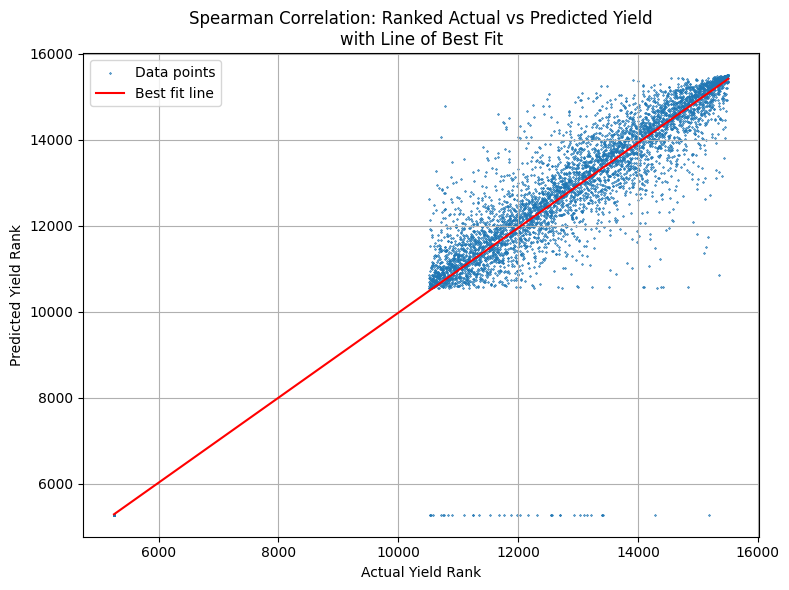

In [34]:
# Spearman's rho graph

# Step 1: Filter and clean data
filtered_best = best_2022_results[best_2022_results['actual_yield'] != "Unknown"].copy()
filtered_best['actual_yield'] = filtered_best['actual_yield'].astype(float)

# Step 2: Compute Spearman's rank correlation
rho, pval = spearmanr(filtered_best['actual_yield'], filtered_best['predicted_yield'])
print(f"Spearman’s rho: {rho:.4f}")
print(f"P-value: {pval:.4g}")

# Step 3: Compute ranks
actual_rank = filtered_best['actual_yield'].rank().values
predicted_rank = filtered_best['predicted_yield'].rank().values

# Step 4: Fit a line of best fit
slope, intercept = np.polyfit(actual_rank, predicted_rank, 1)
line_x = np.linspace(min(actual_rank), max(actual_rank), 100)
line_y = slope * line_x + intercept

# Step 5: Plot
plt.figure(figsize=(8, 6))
plt.scatter(actual_rank, predicted_rank, alpha=0.7, marker='x', s=1, label='Data points')  # 'x' marker with smaller size
plt.plot(line_x, line_y, color='red', label='Best fit line')

plt.title("Spearman Correlation: Ranked Actual vs Predicted Yield\nwith Line of Best Fit")
plt.xlabel("Actual Yield Rank")
plt.ylabel("Predicted Yield Rank")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
# Distance metric extraction

best_2022_results = pd.read_csv("forecast_cv_results_2022.csv")

# Filter to keep only numeric actual yields
filtered_best = best_2022_results[best_2022_results['actual_yield'] != "Unknown"].copy()
filtered_best['actual_yield'] = filtered_best['actual_yield'].astype(float)

# Recalculate MAPE and Median APE per crop
crop_ape_stats = []

for crop, group in filtered_best.groupby('crop'):
    y_actual = group['actual_yield'].values
    y_pred = group['predicted_yield'].values
    valid_mask = y_actual != 0  # avoid divide-by-zero in percentage

    if np.sum(valid_mask) < 1:
        continue  # skip only if there are truly no valid rows

    ape = np.abs((y_actual[valid_mask] - y_pred[valid_mask]) / y_actual[valid_mask]) * 100
    mape = np.mean(ape)
    mdape = np.median(ape)

    crop_ape_stats.append({
        'crop': crop,
        'MAPE (%)': mape,
        'Median APE (%)': mdape,
        'n_valid_samples': np.sum(valid_mask)
    })

crop_ape_df = pd.DataFrame(crop_ape_stats)

# Load model metrics containing train/test R²
model_metrics_df = pd.read_csv('model_metrics_2022.csv')
model_metrics_df = model_metrics_df[['crop', 'train_r2', 'test_r2']]

# Merge APE metrics with R² metrics
comparison_full_df = pd.merge(model_metrics_df, crop_ape_df, on='crop', how='outer')


In [38]:
comparison_full_df.to_csv("comparison_full_df_2022.csv", index=False)